# Machine Learning Modelling

This notebook focuses on preparing the cleaned fintech review dataset for machine learning modelling, including feature selection, train-test splitting, TF-IDF vectorization, and model training/evaluation.

In [1]:

# Import Libraries

import pandas as pd
import numpy as np

# Data splitting
from sklearn.model_selection import train_test_split

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Final Clean Dataset

In [2]:
# Load cleaned dataset

df = pd.read_csv("cleaned_kenya_fintech.csv")

# Preview dataset
df.head()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,...,tokens_no_stopwords,meaningful_tokens,stemmed_tokens,lemmatized_tokens,processed_text,sentiment_label,complaint_label,fraud_indicator,review_length,word_count
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa,...,"['still', 'issues', 'OTP', 'received', 'OTP', ...","['still', 'issues', 'OTP', 'received', 'OTP', ...","['still', 'issu', 'otp', 'receiv', 'otp', 'log...","['still', 'issue', 'OTP', 'received', 'OTP', '...",still issue OTP received OTP login tried every...,negative,app_issue,0,155,23
1,acd5c061-de13-474b-8645-f628044f2a50,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa,...,"['si', 'everytime', 'nitakuwa', 'na', 'bundles...","['everytime', 'nitakuwa', 'bundles', 'check', ...","['everytim', 'nitakuwa', 'bundl', 'check', 'nu...","['everytime', 'nitakuwa', 'bundle', 'check', '...",everytime nitakuwa bundle check number try fix...,negative,general,0,95,16
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa,...,"['stupidest', 'ever', 'saf', 'worst']","['stupidest', 'ever', 'saf', 'worst']","['stupidest', 'ever', 'saf', 'worst']","['stupidest', 'ever', 'saf', 'worst']",stupidest ever saf worst,negative,general,0,24,4
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa,...,"['Life', 'must', 'go', 'without', 'useless', '...","['Life', 'must', 'without', 'useless', 'used',...","['life', 'must', 'without', 'useless', 'use', ...","['Life', 'must', 'without', 'useless', 'used',...",Life must without useless used work well data ...,negative,general,0,64,12
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,Unknown,mpesa,...,"['upgrade', 'terrible']","['upgrade', 'terrible']","['upgrad', 'terribl']","['upgrade', 'terrible']",upgrade terrible,negative,general,0,16,2


In [3]:
# Check dataset shape

df.shape

(53506, 27)

In [4]:
# Check columns

df.columns

Index(['reviewId', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion',
       'at', 'replyContent', 'repliedAt', 'appVersion', 'app_name',
       'sentiment', 'content_no_emojis', 'has_emoji', 'cleaned_text',
       'final_language', 'normalized_text', 'tokens', 'tokens_no_stopwords',
       'meaningful_tokens', 'stemmed_tokens', 'lemmatized_tokens',
       'processed_text', 'sentiment_label', 'complaint_label',
       'fraud_indicator', 'review_length', 'word_count'],
      dtype='object')

## Feature and Target Variables

In [5]:
# Features and target

X = df["processed_text"]

y = df["sentiment_label"]

In [6]:
print(X.head())

0    still issue OTP received OTP login tried every...
1    everytime nitakuwa bundle check number try fix...
2                             stupidest ever saf worst
3    Life must without useless used work well data ...
4                                     upgrade terrible
Name: processed_text, dtype: object


In [7]:
print(y.head())

0    negative
1    negative
2    negative
3    negative
4    negative
Name: sentiment_label, dtype: object


## Verify Class Distribution

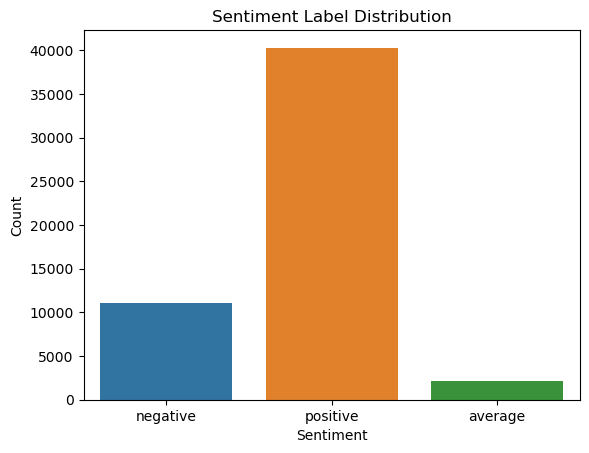

In [20]:
# Plot class distribution

sns.countplot(x=y)

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [21]:
y.unique()

array(['negative', 'positive', 'average'], dtype=object)

### Observation

The dataset shows class imbalance, with positive sentiments having the highest number of reviews compared to negative and average sentiments. This imbalance should be considered during model evaluation.

In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])

[1 1 1 1 1 1 1 1 2 1]


## Train-Test Split

In [23]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Check shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (42804,)
X_test: (10702,)
y_train: (42804,)
y_test: (10702,)


In [24]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 42804
Testing samples: 10702
